# Моделювання епідемії у КШЕ: SIR-модель

## Умова задачі

1 січня студент-першокурсник КШЕ повертається з **Домінікани** 
і приходить на пару з температурою — думає, що просто застудився. 
За тиждень половина його групи кашляє.

Адміністрація університету хоче відповісти на три питання:
1. **Коли буде пік** — скільки людей лежатиме одночасно?
3. **Чи встигнемо ввести карантин** до катастрофи?
4. **Якщо вакцинувати 30% студентів** заздалегідь — наскільки це змінить картину?

## Вхідні дані

| Параметр | Значення |
|---|---|
| Загальна кількість студентів КШЕ, N | 2847 |
| Початково заражених, I₀ | 1 |
| Початково імунних, R₀ | 0 |
| Тривалість хвороби | 7 днів |
| Період моделювання | 180 днів (1 семестр) |

## Математична модель

Популяція студентів КШЕ розділена на три групи:

| Група | Позначення | Опис |
|---|---|---|
| Susceptible | S(t) | Здорові, але вразливі |
| Infected | I(t) | Заражені та заразні |
| Recovered | R(t) | Одужали, мають імунітет |

Система диференціальних рівнянь:

$$\frac{dS}{dt} = -\frac{\beta \cdot S \cdot I}{N}$$

$$\frac{dI}{dt} = \frac{\beta \cdot S \cdot I}{N} - \gamma \cdot I$$

$$\frac{dR}{dt} = \gamma \cdot I$$

**β** — швидкість зараження (кількість контактів на день)  
**γ** — швидкість одужання (1/γ = тривалість хвороби)  
**R₀ = β/γ** — базове репродуктивне число:
- якщо R₀ > 1 — епідемія росте
- якщо R₀ < 1 — епідемія згасає

In [4]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Параметри
N = 2847        # загальна кількість студентів КШЕ
I0 = 1          # початково заражених
R0_init = 0     # початково імунних
S0 = N - I0 - R0_init  # початково здорових

# Часовий проміжок (180 днів = 1 семестр)
t = np.linspace(0, 180, 180)

# Функція SIR моделі
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Три сценарії
# Сценарій A — без втручань
beta_A, gamma_A = 0.4, 1/7

# Сценарій B — карантин на 14-й день
beta_B, gamma_B = 0.15, 1/7

# Сценарій C — вакцинація 30% студентів
beta_C, gamma_C = 0.4, 1/7
S0_C = S0 * 0.7   # 30% вже імунні
R0_C = N - I0 - S0_C

# Розв'язання
sol_A = odeint(sir_model, [S0, I0, R0_init], t, args=(N, beta_A, gamma_A))
sol_B = odeint(sir_model, [S0, I0, R0_init], t, args=(N, beta_B, gamma_B))
sol_C = odeint(sir_model, [S0_C, I0, R0_C], t, args=(N, beta_C, gamma_C))

print("✅ Модель розв'язана успішно!")

✅ Модель розв'язана успішно!


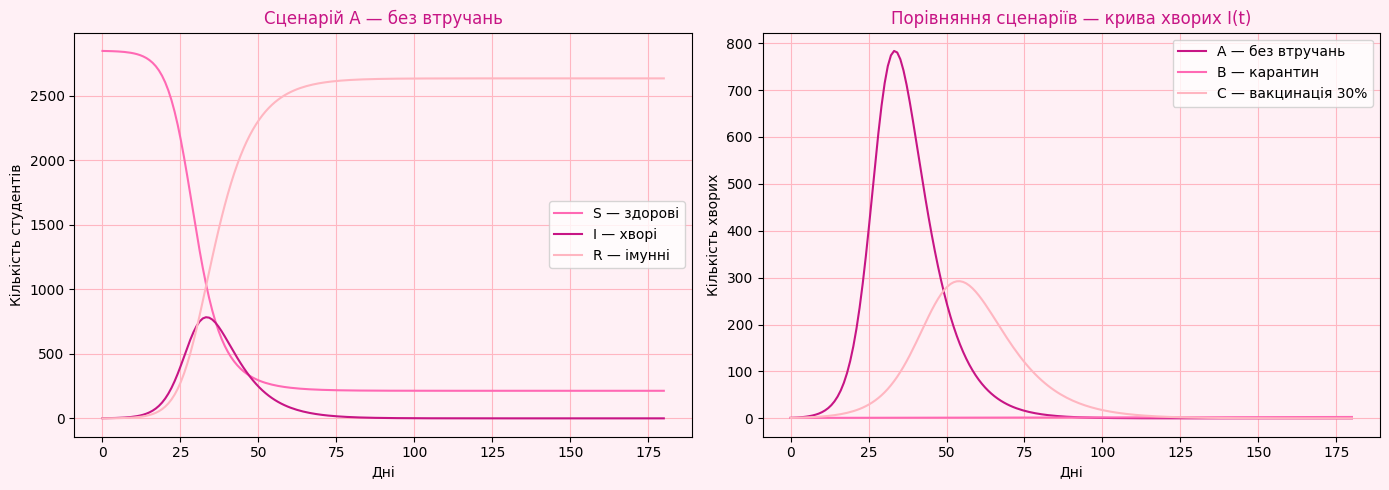

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#fff0f5')

# Графік 1 — Сценарій A (без втручань)
axes[0].plot(t, sol_A[:, 0], color='#ff69b4', label='S — здорові')
axes[0].plot(t, sol_A[:, 1], color='#c71585', label='I — хворі')
axes[0].plot(t, sol_A[:, 2], color='#ffb6c1', label='R — імунні')
axes[0].set_facecolor('#fff0f5')
axes[0].set_title('Сценарій A — без втручань', color='#c71585')
axes[0].set_xlabel('Дні')
axes[0].set_ylabel('Кількість студентів')
axes[0].legend()
axes[0].grid(True, color='#ffb6c1')

# Графік 2 — порівняння піків трьох сценаріїв
axes[1].plot(t, sol_A[:, 1], color='#c71585', label='A — без втручань')
axes[1].plot(t, sol_B[:, 1], color='#ff69b4', label='B — карантин')
axes[1].plot(t, sol_C[:, 1], color='#ffb6c1', label='C — вакцинація 30%')
axes[1].set_facecolor('#fff0f5')
axes[1].set_title('Порівняння сценаріїв — крива хворих I(t)', color='#c71585')
axes[1].set_xlabel('Дні')
axes[1].set_ylabel('Кількість хворих')
axes[1].legend()
axes[1].grid(True, color='#ffb6c1')

plt.tight_layout()
plt.show()